In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\user\my_snippet\DataSets\County_Health_Rankings.csv")
df.head()

,State,County,State code,County code,Year span,Measure name,Measure id,Numerator,Denominator,Raw value,Confidence Interval Lower Bound,Confidence Interval Upper Bound,Data Release Year,fipscode
0,US,United States,0.0,0.0,2003-2005,Violent crime rate,43.0,1328750.667,274877117.0,483.398066,NaN,NaN,NaN,0.0
1,US,United States,0.0,0.0,2004-2006,Violent crime rate,43.0,1340928.667,277612778.5,483.021233,NaN,NaN,NaN,0.0
2,US,United States,0.0,0.0,2005-2007,Violent crime rate,43.0,1355853.167,280407694.7,483.529230,NaN,NaN,2010.0,0.0
3,US,United States,0.0,0.0,2006-2008,Violent crime rate,43.0,1366928.333,287614567.7,475.263942,NaN,NaN,2011.0,0.0
4,US,United States,0.0,0.0,2007-2009,Violent crime rate,43.0,1339439.333,292576281.2,457.808585,NaN,NaN,2012.0,0.0


In [2]:
# Basic cleaning
df.columns = df.columns.str.strip()

df = df.dropna(subset=['State','Raw value'])
df['Raw value'] = pd.to_numeric(df['Raw value'], errors='coerce')

state_df = df[df['State'] != 'US']


In [3]:
#Average Violent Crime Rate bu State
state_crime = (state_df.groupby('State')['Raw value']
               .mean().
               sort_values()
)
top_10_states = state_crime.head(10)




<Axes: ylabel='State'>

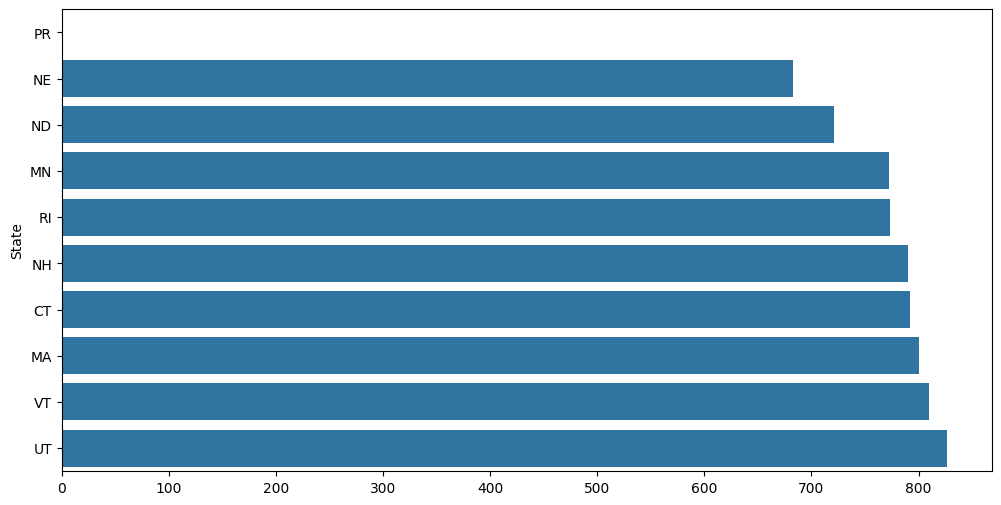

In [4]:
# Visualization
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_10_states.values,
    y=top_10_states.index
)

In [5]:
# counties with highest public safety risk

highest_risky = (df.groupby('County')['Raw value']
                 .mean()
                 .sort_values(ascending=False).head(1))
highest_risky

County
Lake and Peninsula Borough    3528.307218
Name: Raw value, dtype: float64

<Axes: xlabel='State,Measure name'>

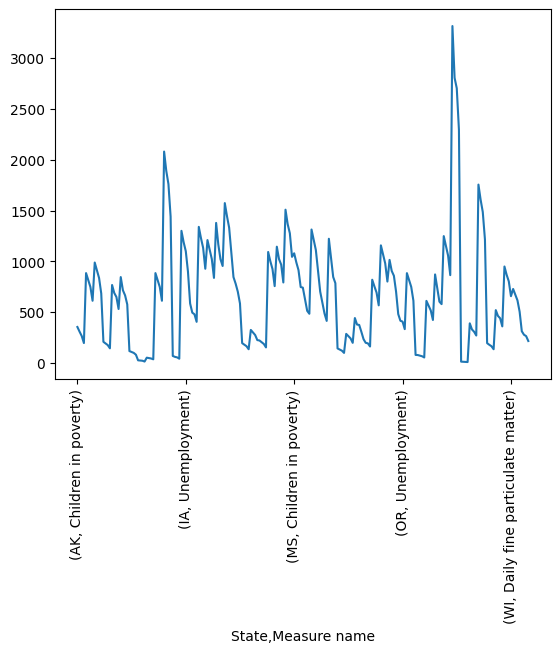

In [6]:
# state wise measure frequency
state_freq = df.groupby(['State'])['Measure name'].value_counts().groupby(level=0).head(4).plot(rot=90)
state_freq


<Axes: xlabel='Raw value', ylabel='Frequency'>

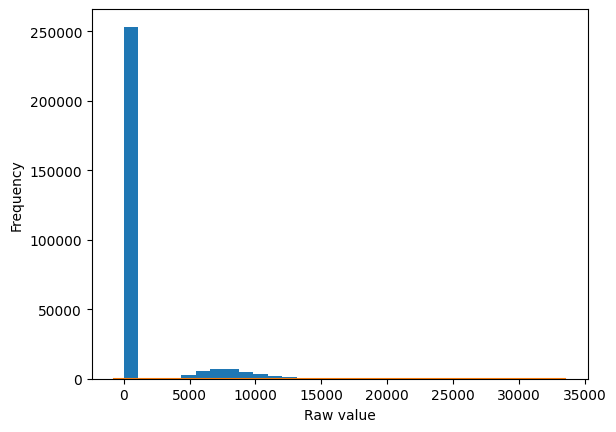

In [7]:
# Raw value distribution
df['Raw value'].plot(kind='hist',bins=30)

# better version
sns.kdeplot(df['Raw value'])

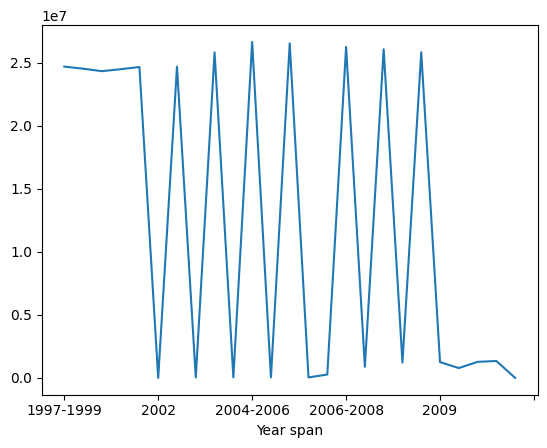

In [8]:
trend_over_time = df.groupby(df['Year span'].dropna())['Raw value'].sum().plot()


In [50]:
# relation between crime rate and population
df['Denominator'] = pd.to_numeric(df['Denominator'],errors='coerce')
df['Denominator'].corr(df['Raw value'])

np.float64(0.030684269402122672)

In [57]:
##3


national = df[df['fipscode'] == 0].copy()
national['start_year'] = national['Year span'].str[:4].astype(int)
national = national.sort_values('start_year')
national[['Year span', 'start_year', 'Raw value']]

,Year span,start_year,Raw value
236824,1997-1999,1997,7705.200000
236825,1998-2000,1998,7615.000000
236826,1999-2001,1999,7568.700000
236827,2000-2002,2000,7535.000000
236828,2001-2003,2001,7498.800000
...,...,...,...
57564,2011,2011,0.225000
22360,2011,2011,0.089520
99148,2011,2011,64.925000
99136,2011,2011,0.841772


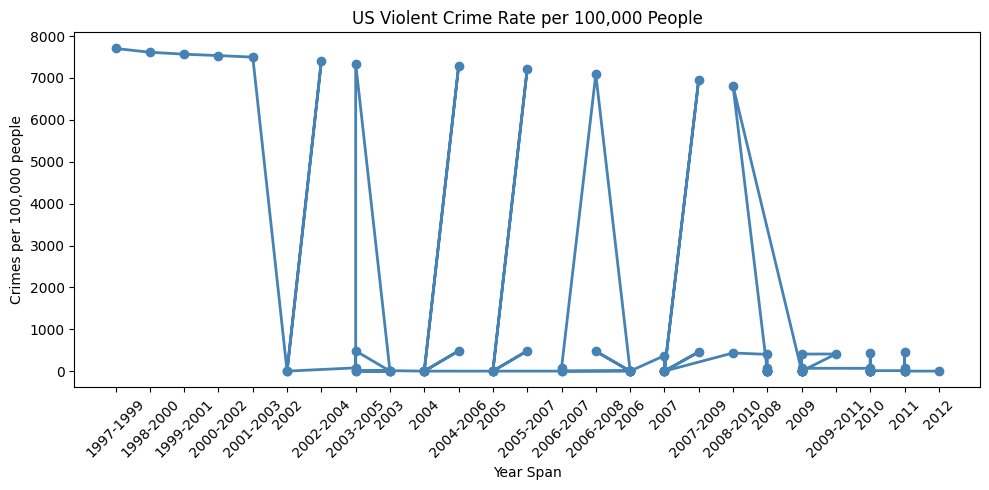

In [60]:
plt.figure(figsize=(10,5))

plt.plot(national['Year span'],national['Raw value'],marker='o',linewidth=2,
            color='steelblue')

plt.title('US Violent Crime Rate per 100,000 People')
plt.xlabel('Year Span')
plt.ylabel('Crimes per 100,000 people')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

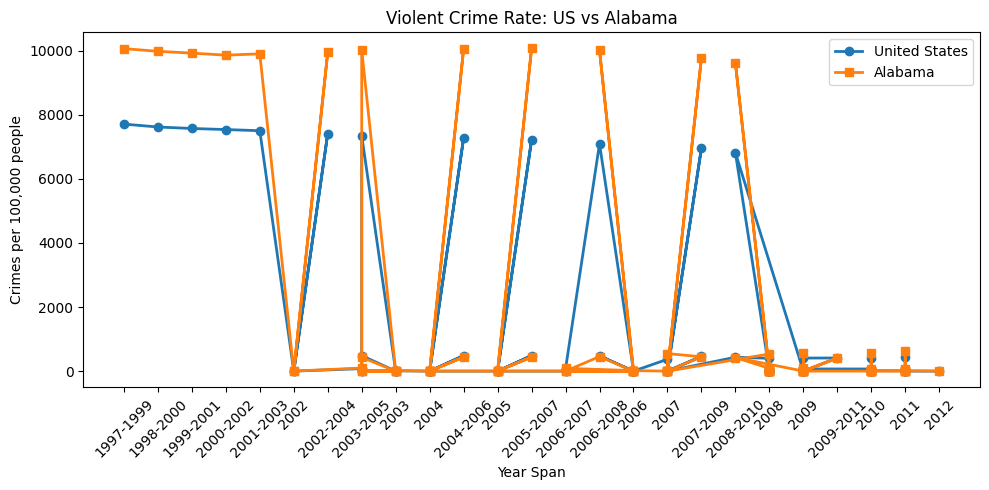

In [61]:
alabama = df[df['fipscode'] == 1000].copy()
alabama['start_year'] = alabama['Year span'].str[:4].astype(int)
alabama = alabama.sort_values('start_year')

plt.figure(figsize=(10, 5))

plt.plot(national['Year span'], national['Raw value'],
         marker='o', label='United States', linewidth=2)

plt.plot(alabama['Year span'], alabama['Raw value'],
         marker='s', label='Alabama', linewidth=2)

plt.title('Violent Crime Rate: US vs Alabama')
plt.xlabel('Year Span')
plt.ylabel('Crimes per 100,000 people')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# Check what fipscode actually looks like
print(df['fipscode'].dtype)
print(df['fipscode'].unique()[:20])  # first 20 unique values

# Check if the filter returns anything
national = df[df['fipscode'] == 0]
print(national.shape)  # if this shows (0, 14) the filter failed

float64
[   0. 1000. 1001. 1003. 1005. 1007. 1009. 1011. 1013. 1015. 1017. 1019.
 1021. 1023. 1025. 1027. 1029. 1031. 1033. 1035.]
(89, 14)


Measure name
Children in poverty                12
Premature Death                    12
Unemployment                       11
Daily fine particulate matter       9
Violent crime rate                  7
Physical inactivity                 7
Adult obesity                       7
Diabetic screening                  6
Mammography screening               6
Preventable hospital stays          6
Sexually transmitted infections     5
Uninsured                           1
Name: count, dtype: int64
(7, 14)
   Year span   Raw value
0  2003-2005  483.398066
1  2004-2006  483.021233
2  2005-2007  483.529230
3  2006-2008  475.263942
4  2007-2009  457.808585
5  2008-2010  433.499335
6  2009-2011  409.362388


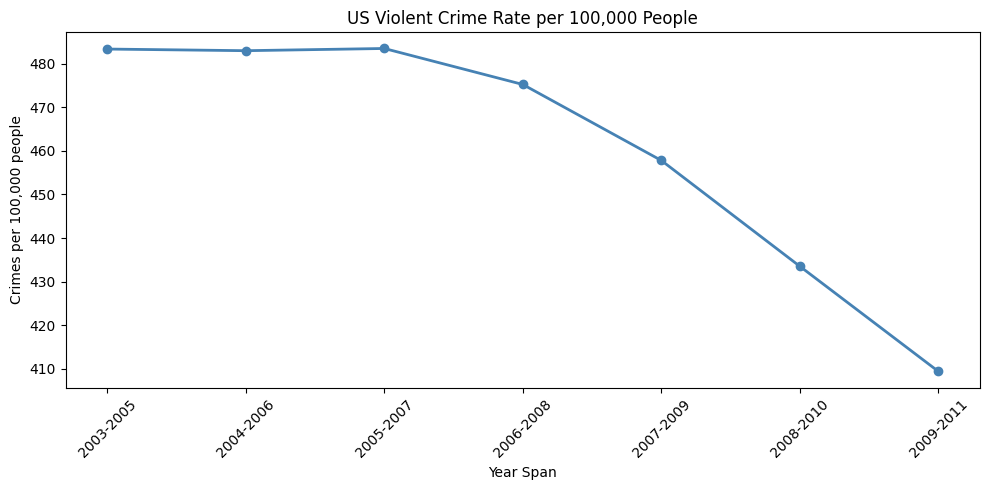

In [63]:
# Check what measures exist at national level
national_all = df[df['fipscode'] == 0]
print(national_all['Measure name'].value_counts())
national = df[
    (df['fipscode'] == 0) &
    (df['Measure name'] == 'Violent crime rate')
].copy()

print(national.shape)  # should now be (7, 14)
print(national[['Year span', 'Raw value']])

national['start_year'] = national['Year span'].str[:4].astype(int)
national = national.sort_values('start_year')

plt.figure(figsize=(10, 5))
plt.plot(national['Year span'], national['Raw value'],
         marker='o', linewidth=2, color='steelblue')

plt.title('US Violent Crime Rate per 100,000 People')
plt.xlabel('Year Span')
plt.ylabel('Crimes per 100,000 people')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()